# Aufbau des Graphen

In [1]:
import logging
import sys
from pathlib import Path

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)
logger = logging.getLogger(__name__)


ROOT = Path.cwd().parent
logger.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

2026-09-17 08:01:31,884 [INFO] __main__: Adding /Users/lukas/Masterarbeit/agents/bxAgent to Python path for imports in kernel.


In [2]:
# Load config with changed env path
from mdeagent.config import Config

config = Config.get_instance(env_path=ROOT / ".env")

In [3]:
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

img_folder = Path("graph_prints")
img_folder.mkdir(exist_ok=True, parents=True)

def get_path(graph: str, suffix: str) -> Path:
    if suffix:
        return img_folder / f"{graph}_Graph_{suffix}.png"
    else:
        return img_folder / f"{graph}_Graph.png"


def display_graph(
    graph, graph_name: str, suffix: str = "", horizontal: bool = True, xray: bool = False
):
    path_name = get_path(graph_name, suffix)
    mermaid = graph.get_graph(xray=xray).draw_mermaid()
    if horizontal:
        mermaid = mermaid.replace("graph TD;", "graph LR;")
    display(Image(draw_mermaid_png(mermaid, output_file_path=path_name)))

## Evaluation Module initialisieren

In [4]:
from mdeagent.evaluation import (
    EvaluationExecutor,
    FileExistenceEvaluation,
    FileExistenceSchema,
    JavaCompilationEvaluation,
    JavaCompilationSchema,
    ToolInstalledEvaluation,
    ToolInstalledSchema,
    WorkspaceStructureEvaluation,
    WorkspaceStructureSchema,
)

executor = EvaluationExecutor(
        evaluations={
            "workspace_structure": {
                "evaluation": WorkspaceStructureEvaluation(),
                "evaluation_schema": WorkspaceStructureSchema,
            },
            "tools_installed": {
                "evaluation": ToolInstalledEvaluation(),
                "evaluation_schema": ToolInstalledSchema,
            },
            "file_existence": {
                "evaluation": FileExistenceEvaluation(),
                "evaluation_schema": FileExistenceSchema,
            },
            "java_compilation": {
                "evaluation": JavaCompilationEvaluation(),
                "evaluation_schema": JavaCompilationSchema,
            },
        }
    )

## MDEAgent Aufbau

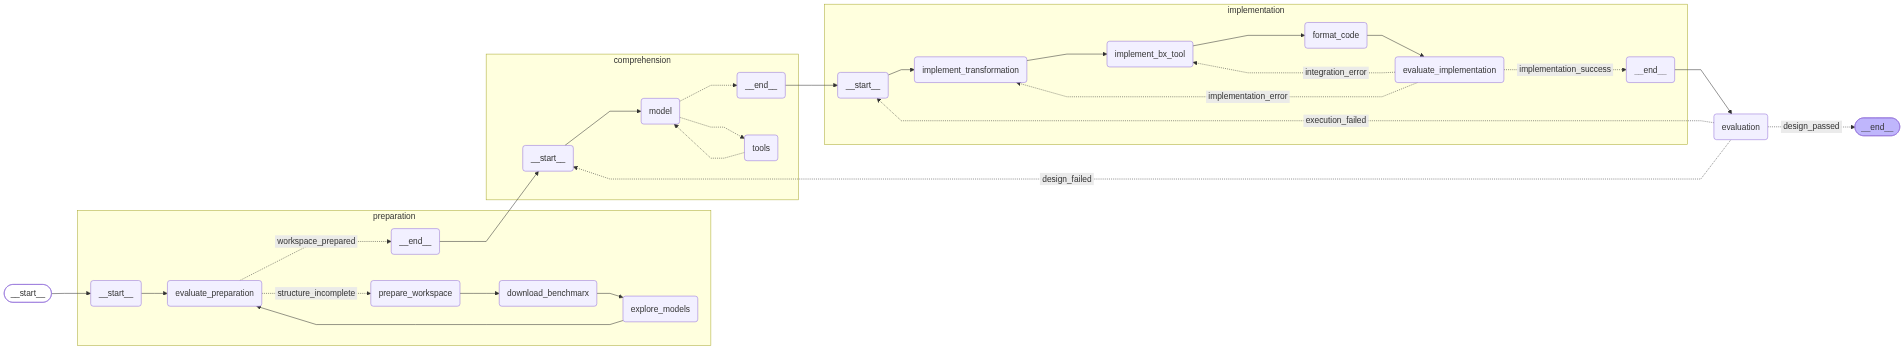

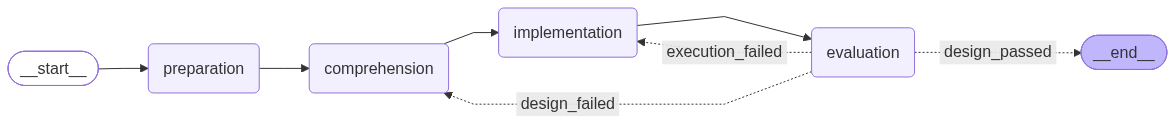

In [5]:
from mdeagent.agent import build_mdeagent

graph = build_mdeagent(executor, Path(), Path()).compile()

display_graph(graph, "MDEAgent", suffix="full", horizontal=True, xray=True)
display_graph(graph, "MDEAgent", horizontal=True, xray=False)

## Preparation Node

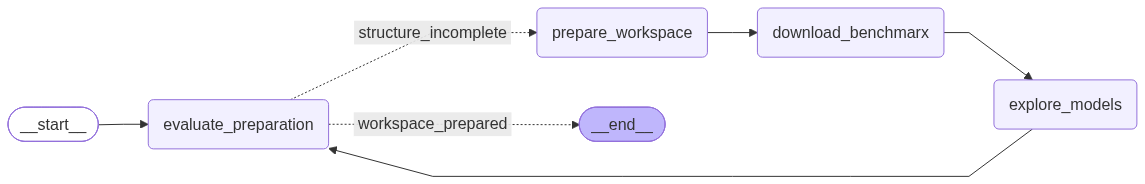

In [6]:
from mdeagent.preparation.agent import build_preparation_graph

preparation_graph = build_preparation_graph(executor, download_benchmarx=True).compile()

display_graph(preparation_graph, "Preparation", horizontal=True, xray=False)

## Comprehension Node

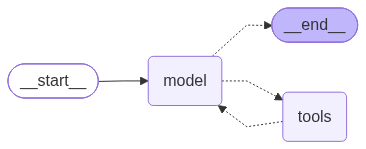

In [7]:
from mdeagent.comprehension.agent import build_comprehension_agent

comprehension_graph = build_comprehension_agent()

display_graph(comprehension_graph, "Comprehension", horizontal=True, xray=False)

## Implementation Node

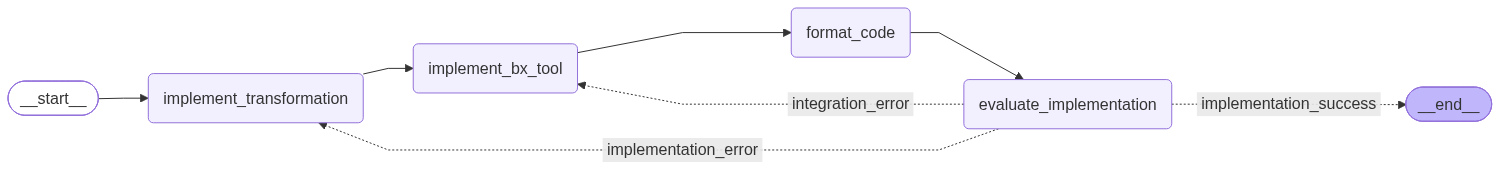

In [8]:
from pathlib import Path

from mdeagent.implementation.agent import build_implementation_graph

implementation_graph = build_implementation_graph(executor, Path(), Path()).compile()

display_graph(implementation_graph, "Implementation", horizontal=True, xray=True)